In [1]:
# Notebook 03 - load annual maximum series for distribution fitting

import pandas as pd
import numpy as np

daily_24h = pd.read_csv('../results/daily_annual_max_24h_1950_2024.csv')
hourly_durations = pd.read_csv('../results/hourly_annual_max_1h_12h_2000_2024.csv')

print('Daily 24h shape:', daily_24h.shape)
print('Hourly durations shape:', hourly_durations.shape)

display(daily_24h.head())
display(hourly_durations.head())

Daily 24h shape: (75, 3)
Hourly durations shape: (25, 6)


,YEAR,valid_days,annual_max_24h_mm
0,1950,365,40.4
1,1951,365,55.5
2,1952,366,27.1
3,1953,365,31.8
4,1954,365,16.1


,YEAR,annual_max_1h_mm,annual_max_2h_mm,annual_max_3h_mm,annual_max_6h_mm,annual_max_12h_mm
0,2000,25.6,44.0,44.0,47.0,52.4
1,2001,31.0,42.4,53.0,85.0,106.2
2,2002,13.4,16.8,17.8,22.2,25.2
3,2003,14.4,18.6,22.4,26.4,26.4
4,2004,18.0,18.8,23.4,25.8,25.8


In [2]:
# Notebook 03 - setup for distribution fitting on the 24-hour annual maxima

from scipy.stats import gumbel_r, genextreme
import matplotlib.pyplot as plt

# Return periods required by the handoff
T = np.array([2, 5, 10, 20, 50, 100], dtype=float)

# Non-exceedance probability corresponding to return period T
F = 1 - 1 / T

# 24-hour annual maximum rainfall series
x_24h = daily_24h['annual_max_24h_mm'].dropna().values

print('24h sample size:', len(x_24h))
print('24h min:', x_24h.min())
print('24h max:', x_24h.max())
print('Return periods:', T)
print('Non-exceedance probabilities:', F)

24h sample size: 75
24h min: 16.1
24h max: 104.2
Return periods: [  2.   5.  10.  20.  50. 100.]
Non-exceedance probabilities: [0.5  0.8  0.9  0.95 0.98 0.99]


In [3]:
# Fit Gumbel distribution to the 24-hour annual maxima

loc_gum_24h, scale_gum_24h = gumbel_r.fit(x_24h)

gumbel_24h_quantiles = gumbel_r.ppf(F, loc=loc_gum_24h, scale=scale_gum_24h)

print('Gumbel 24h parameters')
print('Location:', loc_gum_24h)
print('Scale   :', scale_gum_24h)

gumbel_24h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gumbel_24h_depth_mm': gumbel_24h_quantiles
})

gumbel_24h_results

Gumbel 24h parameters
Location: 31.02836137872803
Scale   : 11.692957587929277


,return_period_years,non_exceedance_prob,gumbel_24h_depth_mm
0,2.0,0.50,35.313981
1,5.0,0.80,48.567096
2,10.0,0.90,57.341811
3,20.0,0.95,65.758728
4,50.0,0.98,76.653565
5,100.0,0.99,84.817711


In [4]:
# Fit GEV distribution to the 24-hour annual maxima

shape_gev_24h, loc_gev_24h, scale_gev_24h = genextreme.fit(x_24h)

gev_24h_quantiles = genextreme.ppf(
    F,
    c=shape_gev_24h,
    loc=loc_gev_24h,
    scale=scale_gev_24h
)

print('GEV 24h parameters')
print('Shape   :', shape_gev_24h)
print('Location:', loc_gev_24h)
print('Scale   :', scale_gev_24h)

gev_24h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gev_24h_depth_mm': gev_24h_quantiles
})

gev_24h_results

GEV 24h parameters
Shape   : -0.29423410446273623
Location: 29.335568723195507
Scale   : 9.917022484705306


,return_period_years,non_exceedance_prob,gev_24h_depth_mm
0,2.0,0.50,33.173510
1,5.0,0.80,48.034139
2,10.0,0.90,60.981669
3,20.0,0.95,76.397759
4,50.0,0.98,101.872633
5,100.0,0.99,126.102310


In [5]:
# Fit Gumbel distribution to the 1-hour annual maxima

x_1h = hourly_durations['annual_max_1h_mm'].dropna().values

loc_gum_1h, scale_gum_1h = gumbel_r.fit(x_1h)

gumbel_1h_quantiles = gumbel_r.ppf(F, loc=loc_gum_1h, scale=scale_gum_1h)

print('Gumbel 1h parameters')
print('Location:', loc_gum_1h)
print('Scale   :', scale_gum_1h)

gumbel_1h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gumbel_1h_depth_mm': gumbel_1h_quantiles
})

gumbel_1h_results

Gumbel 1h parameters
Location: 17.298521352756634
Scale   : 5.762417014303524


,return_period_years,non_exceedance_prob,gumbel_1h_depth_mm
0,2.0,0.50,19.410522
1,5.0,0.80,25.941801
2,10.0,0.90,30.266076
3,20.0,0.95,34.414025
4,50.0,0.98,39.783119
5,100.0,0.99,43.806500


In [6]:
# Fit GEV distribution to the 1-hour annual maxima

shape_gev_1h, loc_gev_1h, scale_gev_1h = genextreme.fit(x_1h)

gev_1h_quantiles = genextreme.ppf(
    F,
    c=shape_gev_1h,
    loc=loc_gev_1h,
    scale=scale_gev_1h
)

print('GEV 1h parameters')
print('Shape   :', shape_gev_1h)
print('Location:', loc_gev_1h)
print('Scale   :', scale_gev_1h)

gev_1h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gev_1h_depth_mm': gev_1h_quantiles
})

gev_1h_results

GEV 1h parameters
Shape   : -0.22115226046394615
Location: 16.638843065638444
Scale   : 5.153107523418713


,return_period_years,non_exceedance_prob,gev_1h_depth_mm
0,2.0,0.50,18.606178
1,5.0,0.80,25.804497
2,10.0,0.90,31.665550
3,20.0,0.95,38.279507
4,50.0,0.98,48.563253
5,100.0,0.99,57.784282


In [7]:
# Compare Gumbel vs GEV for 1-hour rainfall

compare_1h = gumbel_1h_results.merge(
    gev_1h_results,
    on=['return_period_years', 'non_exceedance_prob'],
    how='inner'
)

compare_1h

,return_period_years,non_exceedance_prob,gumbel_1h_depth_mm,gev_1h_depth_mm
0,2.0,0.50,19.410522,18.606178
1,5.0,0.80,25.941801,25.804497
2,10.0,0.90,30.266076,31.665550
3,20.0,0.95,34.414025,38.279507
4,50.0,0.98,39.783119,48.563253
5,100.0,0.99,43.806500,57.784282


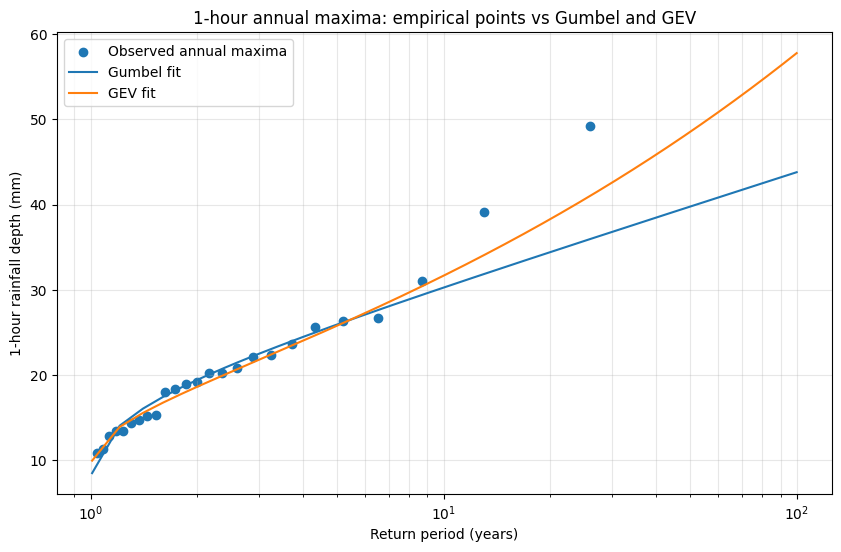

In [8]:
# Plot empirical 1-hour annual maxima against Gumbel and GEV fits

# Sort observed 1-hour annual maxima
x1_sorted = np.sort(x_1h)
n1 = len(x1_sorted)

# Weibull plotting position for non-exceedance probability
F_emp_1h = np.arange(1, n1 + 1) / (n1 + 1)

# Convert empirical probability to return period
T_emp_1h = 1 / (1 - F_emp_1h)

# Smooth return-period range for fitted curves
T_plot = np.linspace(1.01, 100, 500)
F_plot = 1 - 1 / T_plot

# Fitted quantile curves
gumbel_curve_1h = gumbel_r.ppf(F_plot, loc=loc_gum_1h, scale=scale_gum_1h)
gev_curve_1h = genextreme.ppf(F_plot, c=shape_gev_1h, loc=loc_gev_1h, scale=scale_gev_1h)

plt.figure(figsize=(10, 6))
plt.scatter(T_emp_1h, x1_sorted, label='Observed annual maxima')
plt.plot(T_plot, gumbel_curve_1h, label='Gumbel fit')
plt.plot(T_plot, gev_curve_1h, label='GEV fit')

plt.xscale('log')
plt.xlabel('Return period (years)')
plt.ylabel('1-hour rainfall depth (mm)')
plt.title('1-hour annual maxima: empirical points vs Gumbel and GEV')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

In [9]:
# Fit Gumbel distribution to the 2-hour annual maxima

x_2h = hourly_durations['annual_max_2h_mm'].dropna().values

loc_gum_2h, scale_gum_2h = gumbel_r.fit(x_2h)

gumbel_2h_quantiles = gumbel_r.ppf(F, loc=loc_gum_2h, scale=scale_gum_2h)

print('Gumbel 2h parameters')
print('Location:', loc_gum_2h)
print('Scale   :', scale_gum_2h)

gumbel_2h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gumbel_2h_depth_mm': gumbel_2h_quantiles
})

gumbel_2h_results

Gumbel 2h parameters
Location: 20.022798713030635
Scale   : 7.29091179052529


,return_period_years,non_exceedance_prob,gumbel_2h_depth_mm
0,2.0,0.50,22.695012
1,5.0,0.80,30.958729
2,10.0,0.90,36.430028
3,20.0,0.95,41.678230
4,50.0,0.98,48.471489
5,100.0,0.99,53.562081


In [10]:
# Fit GEV distribution to the 2-hour annual maxima

shape_gev_2h, loc_gev_2h, scale_gev_2h = genextreme.fit(x_2h)

gev_2h_quantiles = genextreme.ppf(
    F,
    c=shape_gev_2h,
    loc=loc_gev_2h,
    scale=scale_gev_2h
)

print('GEV 2h parameters')
print('Shape   :', shape_gev_2h)
print('Location:', loc_gev_2h)
print('Scale   :', scale_gev_2h)

gev_2h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gev_2h_depth_mm': gev_2h_quantiles
})

gev_2h_results

GEV 2h parameters
Shape   : -0.2669356380751702
Location: 19.069095613875533
Scale   : 6.328385406070211


,return_period_years,non_exceedance_prob,gev_2h_depth_mm
0,2.0,0.50,21.505784
1,5.0,0.80,30.742751
2,10.0,0.90,38.589893
3,20.0,0.95,47.747794
4,50.0,0.98,62.540470
5,100.0,0.99,76.303867


In [11]:
# Fit GEV distribution to the 2-hour annual maxima

shape_gev_2h, loc_gev_2h, scale_gev_2h = genextreme.fit(x_2h)

gev_2h_quantiles = genextreme.ppf(
    F,
    c=shape_gev_2h,
    loc=loc_gev_2h,
    scale=scale_gev_2h
)

print('GEV 2h parameters')
print('Shape   :', shape_gev_2h)
print('Location:', loc_gev_2h)
print('Scale   :', scale_gev_2h)

gev_2h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gev_2h_depth_mm': gev_2h_quantiles
})

gev_2h_results

GEV 2h parameters
Shape   : -0.2669356380751702
Location: 19.069095613875533
Scale   : 6.328385406070211


,return_period_years,non_exceedance_prob,gev_2h_depth_mm
0,2.0,0.50,21.505784
1,5.0,0.80,30.742751
2,10.0,0.90,38.589893
3,20.0,0.95,47.747794
4,50.0,0.98,62.540470
5,100.0,0.99,76.303867


In [12]:
# Compare Gumbel vs GEV for 2-hour rainfall

compare_2h = gumbel_2h_results.merge(
    gev_2h_results,
    on=['return_period_years', 'non_exceedance_prob'],
    how='inner'
)

compare_2h

,return_period_years,non_exceedance_prob,gumbel_2h_depth_mm,gev_2h_depth_mm
0,2.0,0.50,22.695012,21.505784
1,5.0,0.80,30.958729,30.742751
2,10.0,0.90,36.430028,38.589893
3,20.0,0.95,41.678230,47.747794
4,50.0,0.98,48.471489,62.540470
5,100.0,0.99,53.562081,76.303867


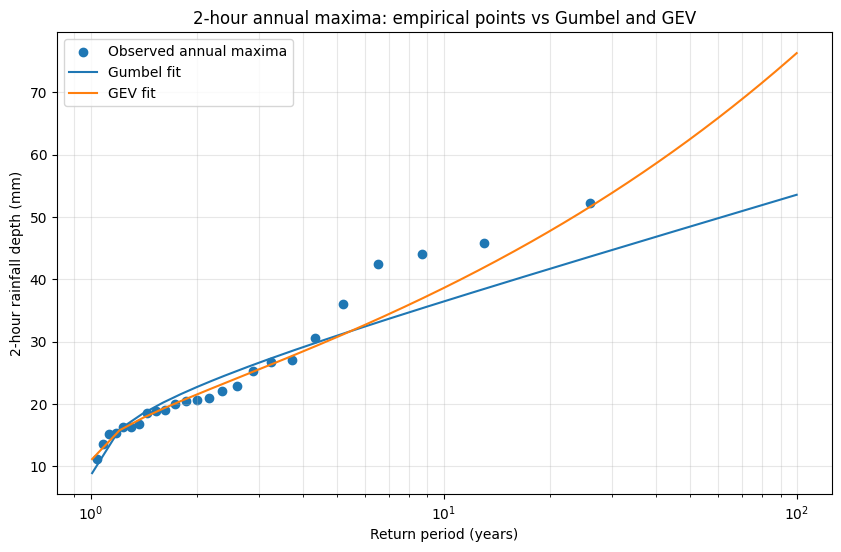

In [13]:
# Plot empirical 2-hour annual maxima against Gumbel and GEV fits

x2_sorted = np.sort(x_2h)
n2 = len(x2_sorted)

F_emp_2h = np.arange(1, n2 + 1) / (n2 + 1)
T_emp_2h = 1 / (1 - F_emp_2h)

T_plot = np.linspace(1.01, 100, 500)
F_plot = 1 - 1 / T_plot

gumbel_curve_2h = gumbel_r.ppf(F_plot, loc=loc_gum_2h, scale=scale_gum_2h)
gev_curve_2h = genextreme.ppf(F_plot, c=shape_gev_2h, loc=loc_gev_2h, scale=scale_gev_2h)

plt.figure(figsize=(10, 6))
plt.scatter(T_emp_2h, x2_sorted, label='Observed annual maxima')
plt.plot(T_plot, gumbel_curve_2h, label='Gumbel fit')
plt.plot(T_plot, gev_curve_2h, label='GEV fit')

plt.xscale('log')
plt.xlabel('Return period (years)')
plt.ylabel('2-hour rainfall depth (mm)')
plt.title('2-hour annual maxima: empirical points vs Gumbel and GEV')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

In [14]:
# Fit Gumbel distribution to the 3-hour annual maxima

x_3h = hourly_durations['annual_max_3h_mm'].dropna().values

loc_gum_3h, scale_gum_3h = gumbel_r.fit(x_3h)

gumbel_3h_quantiles = gumbel_r.ppf(F, loc=loc_gum_3h, scale=scale_gum_3h)

print('Gumbel 3h parameters')
print('Location:', loc_gum_3h)
print('Scale   :', scale_gum_3h)

gumbel_3h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gumbel_3h_depth_mm': gumbel_3h_quantiles
})

gumbel_3h_results

Gumbel 3h parameters
Location: 22.47699973382008
Scale   : 8.375585561261834


,return_period_years,non_exceedance_prob,gumbel_3h_depth_mm
0,2.0,0.50,25.546760
1,5.0,0.80,35.039875
2,10.0,0.90,41.325144
3,20.0,0.95,47.354124
4,50.0,0.98,55.158021
5,100.0,0.99,61.005943


In [15]:
# Fit Gumbel distribution to the 3-hour annual maxima

x_3h = hourly_durations['annual_max_3h_mm'].dropna().values

loc_gum_3h, scale_gum_3h = gumbel_r.fit(x_3h)

gumbel_3h_quantiles = gumbel_r.ppf(F, loc=loc_gum_3h, scale=scale_gum_3h)

print('Gumbel 3h parameters')
print('Location:', loc_gum_3h)
print('Scale   :', scale_gum_3h)

gumbel_3h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gumbel_3h_depth_mm': gumbel_3h_quantiles
})

gumbel_3h_results

Gumbel 3h parameters
Location: 22.47699973382008
Scale   : 8.375585561261834


,return_period_years,non_exceedance_prob,gumbel_3h_depth_mm
0,2.0,0.50,25.546760
1,5.0,0.80,35.039875
2,10.0,0.90,41.325144
3,20.0,0.95,47.354124
4,50.0,0.98,55.158021
5,100.0,0.99,61.005943


In [16]:
# Fit GEV distribution to the 3-hour annual maxima

shape_gev_3h, loc_gev_3h, scale_gev_3h = genextreme.fit(x_3h)

gev_3h_quantiles = genextreme.ppf(
    F,
    c=shape_gev_3h,
    loc=loc_gev_3h,
    scale=scale_gev_3h
)

print('GEV 3h parameters')
print('Shape   :', shape_gev_3h)
print('Location:', loc_gev_3h)
print('Scale   :', scale_gev_3h)

gev_3h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gev_3h_depth_mm': gev_3h_quantiles
})

gev_3h_results

GEV 3h parameters
Shape   : -0.18891677549111474
Location: 21.67350184732613
Scale   : 7.6506482906674655


,return_period_years,non_exceedance_prob,gev_3h_depth_mm
0,2.0,0.50,24.576920
1,5.0,0.80,34.939985
2,10.0,0.90,43.128751
3,20.0,0.95,52.153256
4,50.0,0.98,65.813830
5,100.0,0.99,77.747624


In [17]:
# Compare Gumbel vs GEV for 3-hour rainfall

compare_3h = gumbel_3h_results.merge(
    gev_3h_results,
    on=['return_period_years', 'non_exceedance_prob'],
    how='inner'
)

compare_3h

,return_period_years,non_exceedance_prob,gumbel_3h_depth_mm,gev_3h_depth_mm
0,2.0,0.50,25.546760,24.576920
1,5.0,0.80,35.039875,34.939985
2,10.0,0.90,41.325144,43.128751
3,20.0,0.95,47.354124,52.153256
4,50.0,0.98,55.158021,65.813830
5,100.0,0.99,61.005943,77.747624


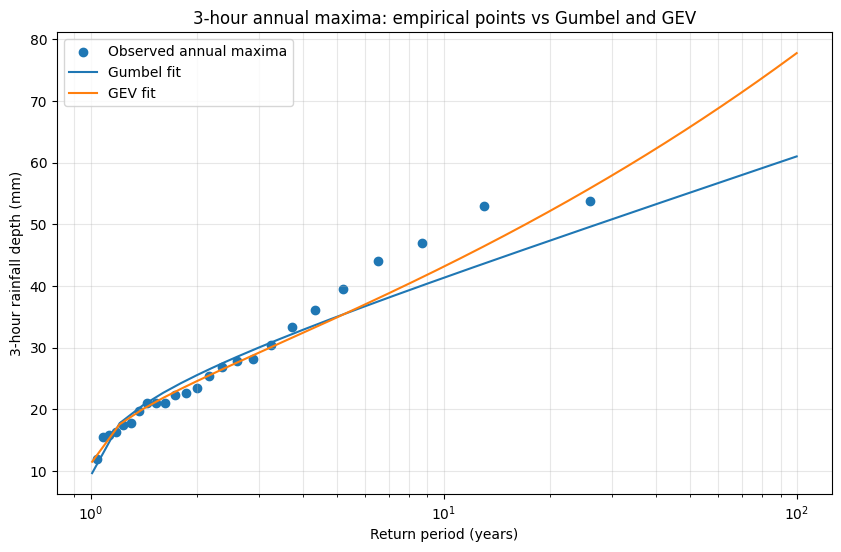

In [18]:
# Plot empirical 3-hour annual maxima against Gumbel and GEV fits

x3_sorted = np.sort(x_3h)
n3 = len(x3_sorted)

F_emp_3h = np.arange(1, n3 + 1) / (n3 + 1)
T_emp_3h = 1 / (1 - F_emp_3h)

T_plot = np.linspace(1.01, 100, 500)
F_plot = 1 - 1 / T_plot

gumbel_curve_3h = gumbel_r.ppf(F_plot, loc=loc_gum_3h, scale=scale_gum_3h)
gev_curve_3h = genextreme.ppf(F_plot, c=shape_gev_3h, loc=loc_gev_3h, scale=scale_gev_3h)

plt.figure(figsize=(10, 6))
plt.scatter(T_emp_3h, x3_sorted, label='Observed annual maxima')
plt.plot(T_plot, gumbel_curve_3h, label='Gumbel fit')
plt.plot(T_plot, gev_curve_3h, label='GEV fit')

plt.xscale('log')
plt.xlabel('Return period (years)')
plt.ylabel('3-hour rainfall depth (mm)')
plt.title('3-hour annual maxima: empirical points vs Gumbel and GEV')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

In [19]:
# Fit Gumbel distribution to the 6-hour annual maxima

x_6h = hourly_durations['annual_max_6h_mm'].dropna().values

loc_gum_6h, scale_gum_6h = gumbel_r.fit(x_6h)

gumbel_6h_quantiles = gumbel_r.ppf(F, loc=loc_gum_6h, scale=scale_gum_6h)

print('Gumbel 6h parameters')
print('Location:', loc_gum_6h)
print('Scale   :', scale_gum_6h)

gumbel_6h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gumbel_6h_depth_mm': gumbel_6h_quantiles
})

gumbel_6h_results

Gumbel 6h parameters
Location: 26.688191335430393
Scale   : 9.552681854519102


,return_period_years,non_exceedance_prob,gumbel_6h_depth_mm
0,2.0,0.50,30.189373
1,5.0,0.80,41.016641
2,10.0,0.90,48.185234
3,20.0,0.95,55.061522
4,50.0,0.98,63.962170
5,100.0,0.99,70.631953


GEV 6h parameters
Shape   : -0.30637128913843636
Location: 25.233155304155503
Scale   : 8.040339191249466

Comparison table:


,return_period_years,non_exceedance_prob,gumbel_6h_depth_mm,gev_6h_depth_mm
0,2.0,0.50,30.189373,28.351866
1,5.0,0.80,41.016641,40.542282
2,10.0,0.90,48.185234,51.283125
3,20.0,0.95,55.061522,64.186244
4,50.0,0.98,63.962170,85.725534
5,100.0,0.99,70.631953,106.413256


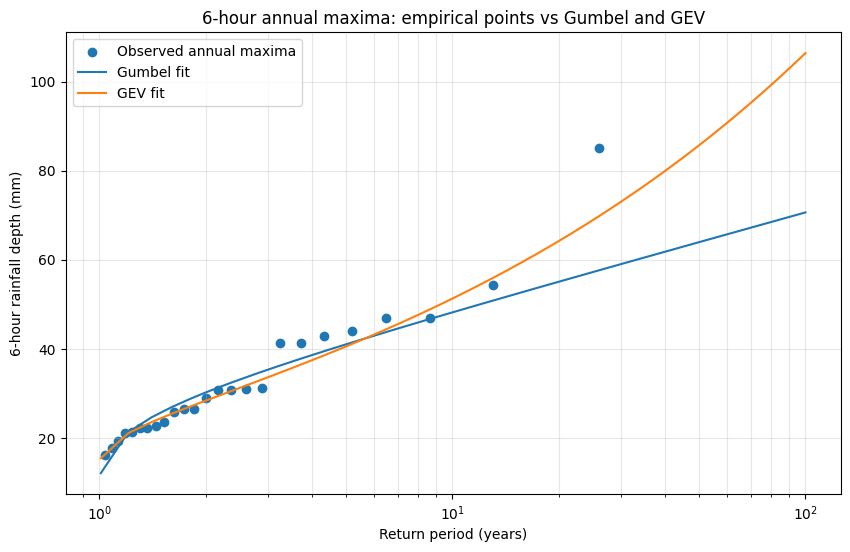

In [20]:
# 6-hour: fit GEV, compare with Gumbel, and plot

# Fit GEV to 6-hour annual maxima
shape_gev_6h, loc_gev_6h, scale_gev_6h = genextreme.fit(x_6h)

gev_6h_quantiles = genextreme.ppf(
    F,
    c=shape_gev_6h,
    loc=loc_gev_6h,
    scale=scale_gev_6h
)

gev_6h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gev_6h_depth_mm': gev_6h_quantiles
})

# Comparison table
compare_6h = gumbel_6h_results.merge(
    gev_6h_results,
    on=['return_period_years', 'non_exceedance_prob'],
    how='inner'
)

print("GEV 6h parameters")
print("Shape   :", shape_gev_6h)
print("Location:", loc_gev_6h)
print("Scale   :", scale_gev_6h)
print("\nComparison table:")
display(compare_6h)

# Plot empirical data vs fitted curves
x6_sorted = np.sort(x_6h)
n6 = len(x6_sorted)

F_emp_6h = np.arange(1, n6 + 1) / (n6 + 1)
T_emp_6h = 1 / (1 - F_emp_6h)

T_plot = np.linspace(1.01, 100, 500)
F_plot = 1 - 1 / T_plot

gumbel_curve_6h = gumbel_r.ppf(F_plot, loc=loc_gum_6h, scale=scale_gum_6h)
gev_curve_6h = genextreme.ppf(F_plot, c=shape_gev_6h, loc=loc_gev_6h, scale=scale_gev_6h)

plt.figure(figsize=(10, 6))
plt.scatter(T_emp_6h, x6_sorted, label='Observed annual maxima')
plt.plot(T_plot, gumbel_curve_6h, label='Gumbel fit')
plt.plot(T_plot, gev_curve_6h, label='GEV fit')

plt.xscale('log')
plt.xlabel('Return period (years)')
plt.ylabel('6-hour rainfall depth (mm)')
plt.title('6-hour annual maxima: empirical points vs Gumbel and GEV')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

Gumbel 12h parameters
Location: 31.945765001991536
Scale   : 12.377658745233859

GEV 12h parameters
Shape   : -0.37104593950267606
Location: 29.744290663505836
Scale   : 9.908258185929947

Comparison table:


,return_period_years,non_exceedance_prob,gumbel_12h_depth_mm,gev_12h_depth_mm
0,2.0,0.50,36.482337,33.634310
1,5.0,0.80,50.511510,49.628777
2,10.0,0.90,59.800044,64.586872
3,20.0,0.95,68.709828,83.429662
4,50.0,0.98,80.242630,116.630814
5,100.0,0.99,88.884842,150.221928


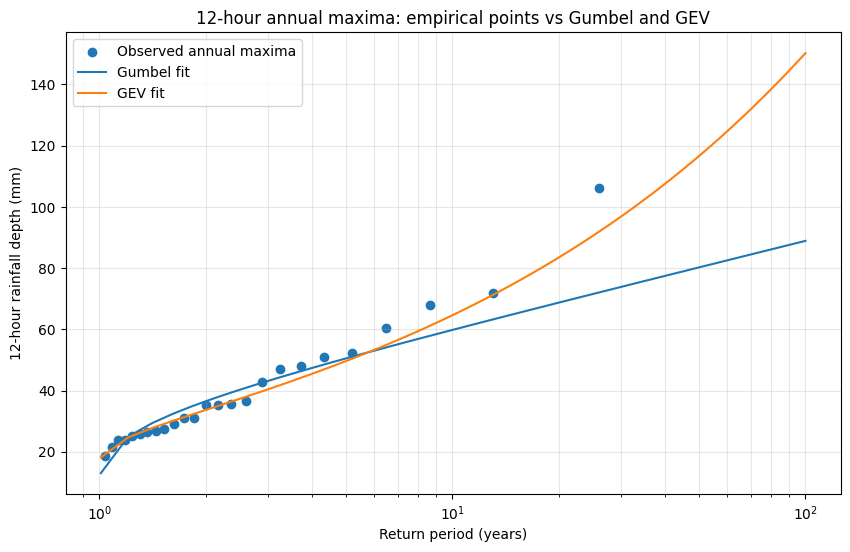

In [21]:
# 12-hour: Gumbel fit, GEV fit, comparison table, and plot

# Prepare 12-hour sample
x_12h = hourly_durations['annual_max_12h_mm'].dropna().values

# --- Gumbel fit ---
loc_gum_12h, scale_gum_12h = gumbel_r.fit(x_12h)

gumbel_12h_quantiles = gumbel_r.ppf(F, loc=loc_gum_12h, scale=scale_gum_12h)

gumbel_12h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gumbel_12h_depth_mm': gumbel_12h_quantiles
})

# --- GEV fit ---
shape_gev_12h, loc_gev_12h, scale_gev_12h = genextreme.fit(x_12h)

gev_12h_quantiles = genextreme.ppf(
    F,
    c=shape_gev_12h,
    loc=loc_gev_12h,
    scale=scale_gev_12h
)

gev_12h_results = pd.DataFrame({
    'return_period_years': T,
    'non_exceedance_prob': F,
    'gev_12h_depth_mm': gev_12h_quantiles
})

# --- Comparison table ---
compare_12h = gumbel_12h_results.merge(
    gev_12h_results,
    on=['return_period_years', 'non_exceedance_prob'],
    how='inner'
)

print("Gumbel 12h parameters")
print("Location:", loc_gum_12h)
print("Scale   :", scale_gum_12h)

print("\nGEV 12h parameters")
print("Shape   :", shape_gev_12h)
print("Location:", loc_gev_12h)
print("Scale   :", scale_gev_12h)

print("\nComparison table:")
display(compare_12h)

# --- Plot empirical data vs fitted curves ---
x12_sorted = np.sort(x_12h)
n12 = len(x12_sorted)

F_emp_12h = np.arange(1, n12 + 1) / (n12 + 1)
T_emp_12h = 1 / (1 - F_emp_12h)

T_plot = np.linspace(1.01, 100, 500)
F_plot = 1 - 1 / T_plot

gumbel_curve_12h = gumbel_r.ppf(F_plot, loc=loc_gum_12h, scale=scale_gum_12h)
gev_curve_12h = genextreme.ppf(F_plot, c=shape_gev_12h, loc=loc_gev_12h, scale=scale_gev_12h)

plt.figure(figsize=(10, 6))
plt.scatter(T_emp_12h, x12_sorted, label='Observed annual maxima')
plt.plot(T_plot, gumbel_curve_12h, label='Gumbel fit')
plt.plot(T_plot, gev_curve_12h, label='GEV fit')

plt.xscale('log')
plt.xlabel('Return period (years)')
plt.ylabel('12-hour rainfall depth (mm)')
plt.title('12-hour annual maxima: empirical points vs Gumbel and GEV')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

24-hour comparison table:


,return_period_years,non_exceedance_prob,gumbel_24h_depth_mm,gev_24h_depth_mm
0,2.0,0.50,35.313981,33.173510
1,5.0,0.80,48.567096,48.034139
2,10.0,0.90,57.341811,60.981669
3,20.0,0.95,65.758728,76.397759
4,50.0,0.98,76.653565,101.872633
5,100.0,0.99,84.817711,126.102310


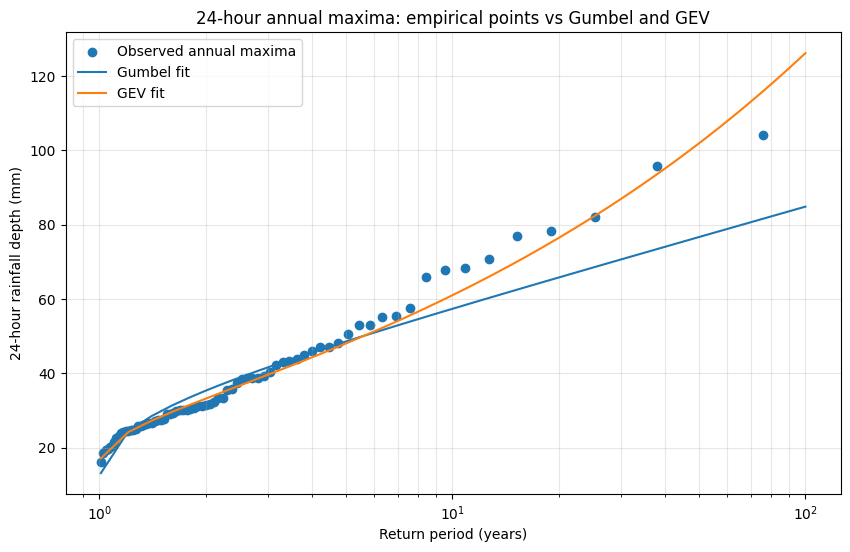

In [22]:
# 24-hour: comparison table + empirical plot for Gumbel vs GEV

compare_24h = gumbel_24h_results.merge(
    gev_24h_results,
    on=['return_period_years', 'non_exceedance_prob'],
    how='inner'
)

print("24-hour comparison table:")
display(compare_24h)

# Empirical points
x24_sorted = np.sort(x_24h)
n24 = len(x24_sorted)

F_emp_24h = np.arange(1, n24 + 1) / (n24 + 1)
T_emp_24h = 1 / (1 - F_emp_24h)

# Smooth fitted curves
T_plot = np.linspace(1.01, 100, 500)
F_plot = 1 - 1 / T_plot

gumbel_curve_24h = gumbel_r.ppf(F_plot, loc=loc_gum_24h, scale=scale_gum_24h)
gev_curve_24h = genextreme.ppf(F_plot, c=shape_gev_24h, loc=loc_gev_24h, scale=scale_gev_24h)

plt.figure(figsize=(10, 6))
plt.scatter(T_emp_24h, x24_sorted, label='Observed annual maxima')
plt.plot(T_plot, gumbel_curve_24h, label='Gumbel fit')
plt.plot(T_plot, gev_curve_24h, label='GEV fit')

plt.xscale('log')
plt.xlabel('Return period (years)')
plt.ylabel('24-hour rainfall depth (mm)')
plt.title('24-hour annual maxima: empirical points vs Gumbel and GEV')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()


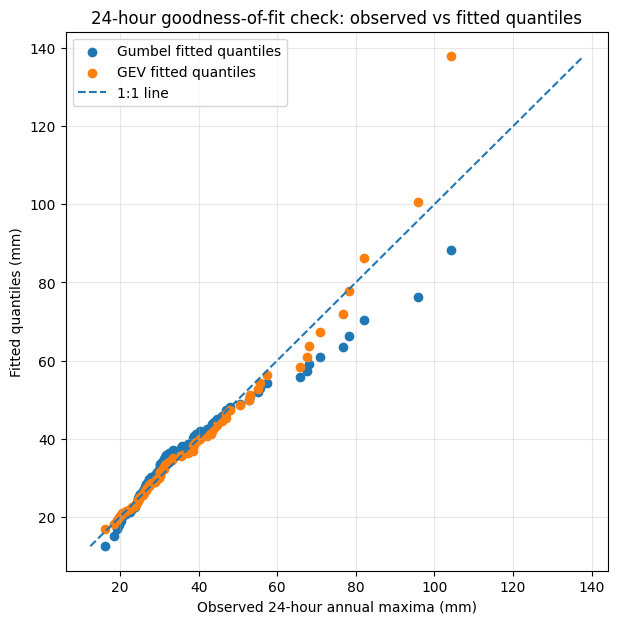

In [23]:
# Goodness-of-fit check for 24h: observed vs fitted quantiles using Gringorten plotting position

x24_sorted = np.sort(x_24h)
n24 = len(x24_sorted)

# Gringorten plotting position from the handoff
p24 = (np.arange(1, n24 + 1) - 0.44) / (n24 + 0.12)

gumbel_fit_points_24h = gumbel_r.ppf(p24, loc=loc_gum_24h, scale=scale_gum_24h)
gev_fit_points_24h = genextreme.ppf(p24, c=shape_gev_24h, loc=loc_gev_24h, scale=scale_gev_24h)

plt.figure(figsize=(7, 7))
plt.scatter(x24_sorted, gumbel_fit_points_24h, label='Gumbel fitted quantiles')
plt.scatter(x24_sorted, gev_fit_points_24h, label='GEV fitted quantiles')

min_val = min(x24_sorted.min(), gumbel_fit_points_24h.min(), gev_fit_points_24h.min())
max_val = max(x24_sorted.max(), gumbel_fit_points_24h.max(), gev_fit_points_24h.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label='1:1 line')

plt.xlabel('Observed 24-hour annual maxima (mm)')
plt.ylabel('Fitted quantiles (mm)')
plt.title('24-hour goodness-of-fit check: observed vs fitted quantiles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# Compact goodness-of-fit summary using RMSE between observed and fitted quantiles

def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.sqrt(np.mean((a - b) ** 2))

gof_rows = []

# 24h
x24_sorted = np.sort(x_24h)
n24 = len(x24_sorted)
p24 = (np.arange(1, n24 + 1) - 0.44) / (n24 + 0.12)

gof_rows.append({
    'duration': '24h',
    'model': 'Gumbel',
    'rmse_mm': rmse(x24_sorted, gumbel_r.ppf(p24, loc=loc_gum_24h, scale=scale_gum_24h))
})
gof_rows.append({
    'duration': '24h',
    'model': 'GEV',
    'rmse_mm': rmse(x24_sorted, genextreme.ppf(p24, c=shape_gev_24h, loc=loc_gev_24h, scale=scale_gev_24h))
})

# 1h
x1_sorted = np.sort(x_1h)
n1 = len(x1_sorted)
p1 = (np.arange(1, n1 + 1) - 0.44) / (n1 + 0.12)

gof_rows.append({
    'duration': '1h',
    'model': 'Gumbel',
    'rmse_mm': rmse(x1_sorted, gumbel_r.ppf(p1, loc=loc_gum_1h, scale=scale_gum_1h))
})
gof_rows.append({
    'duration': '1h',
    'model': 'GEV',
    'rmse_mm': rmse(x1_sorted, genextreme.ppf(p1, c=shape_gev_1h, loc=loc_gev_1h, scale=scale_gev_1h))
})

# 2h
x2_sorted = np.sort(x_2h)
n2 = len(x2_sorted)
p2 = (np.arange(1, n2 + 1) - 0.44) / (n2 + 0.12)

gof_rows.append({
    'duration': '2h',
    'model': 'Gumbel',
    'rmse_mm': rmse(x2_sorted, gumbel_r.ppf(p2, loc=loc_gum_2h, scale=scale_gum_2h))
})
gof_rows.append({
    'duration': '2h',
    'model': 'GEV',
    'rmse_mm': rmse(x2_sorted, genextreme.ppf(p2, c=shape_gev_2h, loc=loc_gev_2h, scale=scale_gev_2h))
})

# 3h
x3_sorted = np.sort(x_3h)
n3 = len(x3_sorted)
p3 = (np.arange(1, n3 + 1) - 0.44) / (n3 + 0.12)

gof_rows.append({
    'duration': '3h',
    'model': 'Gumbel',
    'rmse_mm': rmse(x3_sorted, gumbel_r.ppf(p3, loc=loc_gum_3h, scale=scale_gum_3h))
})
gof_rows.append({
    'duration': '3h',
    'model': 'GEV',
    'rmse_mm': rmse(x3_sorted, genextreme.ppf(p3, c=shape_gev_3h, loc=loc_gev_3h, scale=scale_gev_3h))
})

# 6h
x6_sorted = np.sort(x_6h)
n6 = len(x6_sorted)
p6 = (np.arange(1, n6 + 1) - 0.44) / (n6 + 0.12)

gof_rows.append({
    'duration': '6h',
    'model': 'Gumbel',
    'rmse_mm': rmse(x6_sorted, gumbel_r.ppf(p6, loc=loc_gum_6h, scale=scale_gum_6h))
})
gof_rows.append({
    'duration': '6h',
    'model': 'GEV',
    'rmse_mm': rmse(x6_sorted, genextreme.ppf(p6, c=shape_gev_6h, loc=loc_gev_6h, scale=scale_gev_6h))
})

# 12h
x12_sorted = np.sort(x_12h)
n12 = len(x12_sorted)
p12 = (np.arange(1, n12 + 1) - 0.44) / (n12 + 0.12)

gof_rows.append({
    'duration': '12h',
    'model': 'Gumbel',
    'rmse_mm': rmse(x12_sorted, gumbel_r.ppf(p12, loc=loc_gum_12h, scale=scale_gum_12h))
})
gof_rows.append({
    'duration': '12h',
    'model': 'GEV',
    'rmse_mm': rmse(x12_sorted, genextreme.ppf(p12, c=shape_gev_12h, loc=loc_gev_12h, scale=scale_gev_12h))
})

gof_summary = pd.DataFrame(gof_rows).sort_values(['duration', 'rmse_mm'])
gof_summary

,duration,model,rmse_mm
11,12h,GEV,2.554969
10,12h,Gumbel,6.360076
3,1h,GEV,0.985699
2,1h,Gumbel,2.439544
1,24h,GEV,4.344937
0,24h,Gumbel,4.853423
5,2h,GEV,2.790945
4,2h,Gumbel,3.140176
6,3h,Gumbel,2.586509
7,3h,GEV,2.753928


In [27]:
# Load annual maxima from NB02
import pandas as pd
import numpy as np
from scipy.stats import genextreme, kstest
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

am_daily  = pd.read_csv('../results/daily_annual_max_24h_1950_2024.csv')
am_hourly = pd.read_csv('../results/hourly_annual_max_1h_12h_2000_2024.csv')

print("Daily columns:",  am_daily.columns.tolist())
print("Hourly columns:", am_hourly.columns.tolist())
print()
print(am_daily.head(3))
print(am_hourly.head(3))

Daily columns: ['YEAR', 'valid_days', 'annual_max_24h_mm']
Hourly columns: ['YEAR', 'annual_max_1h_mm', 'annual_max_2h_mm', 'annual_max_3h_mm', 'annual_max_6h_mm', 'annual_max_12h_mm']

   YEAR  valid_days  annual_max_24h_mm
0  1950         365               40.4
1  1951         365               55.5
2  1952         366               27.1
   YEAR  annual_max_1h_mm  annual_max_2h_mm  annual_max_3h_mm  \
0  2000              25.6              44.0              44.0   
1  2001              31.0              42.4              53.0   
2  2002              13.4              16.8              17.8   

   annual_max_6h_mm  annual_max_12h_mm  
0              47.0               52.4  
1              85.0              106.2  
2              22.2               25.2  


In [28]:
# Bundle all durations into one dictionary
am_daily  = am_daily.set_index('YEAR')
am_hourly = am_hourly.set_index('YEAR')

duration_data = {
    1:  am_hourly['annual_max_1h_mm'].dropna(),
    2:  am_hourly['annual_max_2h_mm'].dropna(),
    3:  am_hourly['annual_max_3h_mm'].dropna(),
    6:  am_hourly['annual_max_6h_mm'].dropna(),
    12: am_hourly['annual_max_12h_mm'].dropna(),
    24: am_daily['annual_max_24h_mm'].dropna(),
}

print("Sample sizes per duration:")
for d, s in duration_data.items():
    print(f"  {d:>3}h  n={len(s)}  mean={s.mean():.1f} mm  max={s.max():.1f} mm")

Sample sizes per duration:
    1h  n=25  mean=20.9 mm  max=49.2 mm
    2h  n=25  mean=24.7 mm  max=52.2 mm
    3h  n=25  mean=27.7 mm  max=53.8 mm
    6h  n=25  mean=32.8 mm  max=85.0 mm
   12h  n=25  mean=40.0 mm  max=106.2 mm
   24h  n=75  mean=38.6 mm  max=104.2 mm


In [29]:
def fit_gumbel_lmom(data):
    """
    Fit Gumbel (EV Type I) via L-moments.
    More robust than MLE for small samples (n=25).
    Returns: mu (location), alpha (scale)
    """
    x = np.sort(np.array(data, dtype=float))
    n = len(x)
    b0 = np.mean(x)
    b1 = np.sum([(i / (n - 1)) * x[i] for i in range(n)]) / n
    l2 = 2 * b1 - b0
    alpha = l2 / np.log(2)
    mu = b0 - 0.5772156649 * alpha
    return mu, alpha
 
def gumbel_quantile(T, mu, alpha):
    return mu - alpha * np.log(-np.log(1 - 1/T))
 
def gumbel_cdf(x, mu, alpha):
    return np.exp(-np.exp(-(x - mu) / alpha))
 
def gringorten_pp(n):
    i = np.arange(1, n + 1)
    return (i - 0.44) / (n + 0.12)
 
print("Utility functions ready.")

Utility functions ready.


In [30]:
return_periods = [2, 5, 10, 20, 50, 100]
fit_results = {}
 
print(f"{'Dur':>5}  {'n':>4}  {'KS_Gumbel p':>12}  {'KS_GEV p':>10}  {'xi(GEV)':>8}")
print("-" * 50)
 
for dur, series in duration_data.items():
    x = series.values
 
    # Gumbel via L-moments
    mu, alpha = fit_gumbel_lmom(x)
 
    # GEV via MLE
    shape_g, loc_g, scale_g = genextreme.fit(x, method='mle')
 
    # KS goodness-of-fit
    ks_gum, p_gum = kstest(x, lambda v: gumbel_cdf(v, mu, alpha))
    ks_gev, p_gev = kstest(x, lambda v: genextreme.cdf(
        v, shape_g, loc=loc_g, scale=scale_g))
 
    row = dict(n=len(x), mu=mu, alpha=alpha,
               shape_gev=shape_g, loc_gev=loc_g, scale_gev=scale_g,
               ks_gumbel=ks_gum, p_gumbel=p_gum,
               ks_gev=ks_gev, p_gev=p_gev)
 
    for T in return_periods:
        row[f'gumbel_{T}yr'] = gumbel_quantile(T, mu, alpha)
        row[f'gev_{T}yr'] = genextreme.ppf(
            1 - 1/T, shape_g, loc=loc_g, scale=scale_g)
 
    fit_results[dur] = row
    print(f"{dur:>4}h  {len(x):>4}  {p_gum:>12.4f}  {p_gev:>10.4f}  {shape_g:>+8.3f}")
 
print("\nNote: p > 0.05 means the distribution fits (cannot reject H0)")
print("xi > 0 = Frechet (heavier tail)  |  xi < 0 = Weibull (bounded)")

  Dur     n   KS_Gumbel p    KS_GEV p   xi(GEV)
--------------------------------------------------
   1h    25        0.9761      0.9367    -0.221
   2h    25        0.6562      0.9846    -0.267
   3h    25        0.9158      0.9985    -0.189
   6h    25        0.5166      0.7312    -0.306
  12h    25        0.6213      0.9755    -0.371
  24h    75        0.1841      0.8894    -0.294

Note: p > 0.05 means the distribution fits (cannot reject H0)
xi > 0 = Frechet (heavier tail)  |  xi < 0 = Weibull (bounded)


In [31]:
def make_table(prefix):
    return pd.DataFrame(
        {dur: {T: fit_results[dur][f'{prefix}_{T}yr']
               for T in return_periods}
         for dur in duration_data}
    ).T.rename_axis('duration_h').rename_axis('return_period_yr', axis=1)
 
gumbel_table = make_table('gumbel')
gev_table    = make_table('gev')
 
print("GEV design rainfall depths (mm):")
print(gev_table.round(1))
print()
print("Gumbel design rainfall depths (mm):")
print(gumbel_table.round(1))
 
gumbel_table.round(2).to_csv('../results/design_rainfall_gumbel.csv')
gev_table.round(2).to_csv('../results/design_rainfall_gev.csv')
print("\nSaved: results/design_rainfall_gumbel.csv")
print("Saved: results/design_rainfall_gev.csv")

GEV design rainfall depths (mm):
return_period_yr   2     5     10    20     50     100
duration_h                                            
1                 18.6  25.8  31.7  38.3   48.6   57.8
2                 21.5  30.7  38.6  47.7   62.5   76.3
3                 24.6  34.9  43.1  52.2   65.8   77.7
6                 28.4  40.5  51.3  64.2   85.7  106.4
12                33.6  49.6  64.6  83.4  116.6  150.2
24                33.2  48.0  61.0  76.4  101.9  126.1

Gumbel design rainfall depths (mm):
return_period_yr   2     5     10    20    50     100
duration_h                                           
1                 19.5  27.0  32.0  36.8  43.0   47.6
2                 22.9  32.6  39.0  45.2  53.2   59.2
3                 25.7  36.4  43.5  50.3  59.1   65.8
6                 30.5  43.2  51.6  59.7  70.2   78.0
12                36.9  53.8  65.0  75.7  89.6  100.0
24                35.7  51.2  61.4  71.2  83.9   93.4

Saved: results/design_rainfall_gumbel.csv
Saved: results/

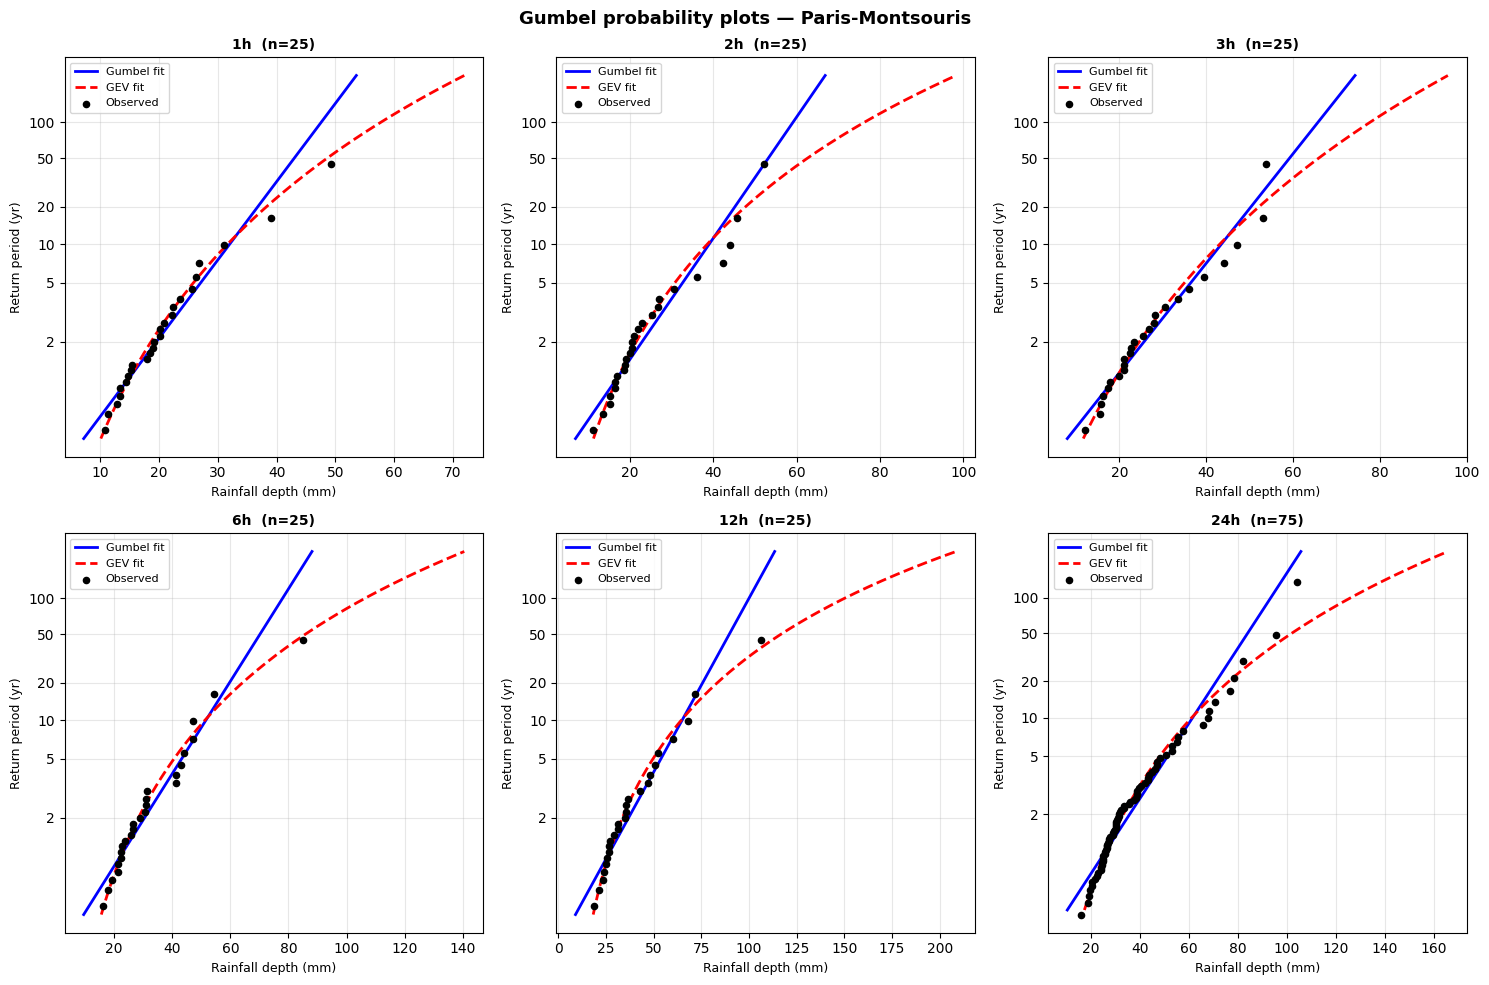

Saved: results/probability_plots_all_durations.png


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
 
for idx, dur in enumerate(sorted(duration_data.keys())):
    ax = axes[idx]
    x  = np.sort(duration_data[dur].values)
    n  = len(x)
    p  = gringorten_pp(n)
 
    # Gumbel reduced variate for y-axis
    y_obs = -np.log(-np.log(p))
 
    mu    = fit_results[dur]['mu']
    alpha = fit_results[dur]['alpha']
    y_fit = np.linspace(-1.5, 5.5, 300)
    x_gum = mu + alpha * y_fit
 
    shape_g = fit_results[dur]['shape_gev']
    loc_g   = fit_results[dur]['loc_gev']
    scale_g = fit_results[dur]['scale_gev']
    p_fit   = np.exp(-np.exp(-y_fit))
    x_gev   = genextreme.ppf(p_fit, shape_g, loc=loc_g, scale=scale_g)
 
    ax.plot(x_gum, y_fit, 'b-',  lw=2,   label='Gumbel fit')
    ax.plot(x_gev, y_fit, 'r--', lw=2,   label='GEV fit')
    ax.scatter(x, y_obs,  color='k', s=20, zorder=5, label='Observed')
 
    rp_ticks = [2, 5, 10, 20, 50, 100]
    ax.set_yticks([-np.log(-np.log(1 - 1/T)) for T in rp_ticks])
    ax.set_yticklabels([str(T) for T in rp_ticks])
    ax.set_xlabel('Rainfall depth (mm)', fontsize=9)
    ax.set_ylabel('Return period (yr)',  fontsize=9)
    ax.set_title(f'{dur}h  (n={n})', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.suptitle('Gumbel probability plots — Paris-Montsouris',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/probability_plots_all_durations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/probability_plots_all_durations.png")
 

In [33]:
ks_df = pd.DataFrame({
    'n':             {d: fit_results[d]['n']         for d in duration_data},
    'KS_Gumbel':     {d: fit_results[d]['ks_gumbel'] for d in duration_data},
    'p_Gumbel':      {d: fit_results[d]['p_gumbel']  for d in duration_data},
    'KS_GEV':        {d: fit_results[d]['ks_gev']    for d in duration_data},
    'p_GEV':         {d: fit_results[d]['p_gev']     for d in duration_data},
    'xi_GEV(shape)': {d: fit_results[d]['shape_gev'] for d in duration_data},
}).rename_axis('duration_h')
 
print("KS goodness-of-fit summary:")
print(ks_df.round(4))
ks_df.round(4).to_csv('../results/ks_test_summary.csv')
print("\nSaved: results/ks_test_summary.csv")
print("\nNB03 COMPLETE")

KS goodness-of-fit summary:
             n  KS_Gumbel  p_Gumbel  KS_GEV   p_GEV  xi_GEV(shape)
duration_h                                                        
1           25     0.0901    0.9761  0.1014  0.9367        -0.2212
2           25     0.1405    0.6562  0.0861  0.9846        -0.2669
3           25     0.1056    0.9158  0.0714  0.9985        -0.1889
6           25     0.1572    0.5166  0.1316  0.7312        -0.3064
12          25     0.1446    0.6213  0.0903  0.9755        -0.3710
24          75     0.1238    0.1841  0.0649  0.8894        -0.2942

Saved: results/ks_test_summary.csv

NB03 COMPLETE
